
# Practical Bayesian Inference

### Adrian Brasoveanu, 11/12/2019

Based on materials from:

- https://github.com/dkirkby/kavli2019
- https://github.com/pymc-devs/resources/tree/master/BCM
- https://github.com/hse-aml/bayesian-methods-for-ml
- https://sites.google.com/site/doingbayesiandataanalysis/
- http://people.duke.edu/~ccc14/cspy/

"Practical" means that we will move pretty fast through the foundations needed for the tutorial one week from today.

In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd
import scipy.stats

## Bayes Introduction / Review

What is a probability?

**Frequentist**: measures likelihood of different outcomes of an uncertain but infinitely repeatable process.
 - e.g., given a coin, measure probability of H using a large number of trials.

**Bayesian:** a probability can be assigned to any statement.

This necessarily requires some subjective input when you cannot simply measure frequencies.

Roughly speaking, the two extremes are:
   - objective probabilities of uninteresting statements.
   - subjective probabilities of interesting statements.

In practice, any sensible methodology gives consistent answers with sufficiently informative data.

Whatever you consider your valid probabilities, $P(A)$ and $P(B)$, for (outcomes or statements) $A$ and $B$, you can always define the conditional probabilities:

$$
P(A\mid B) \equiv \frac{P(A\,\text{and}\,B)}{P(B)} \quad,\quad
P(B\mid A) \equiv \frac{P(A\,\text{and}\,B)}{P(A)}
$$

*($A$ and $B$ are random variables or logical propositions about possible outcomes)*

Bayes' rule is then just a consequence of this definition and entirely uncontroversial:

$$
\boxed{
P(A\mid B) = \frac{P(B\mid A) P(A)}{P(B)}
}
$$

Bayesian statistics starts from a joint probability distribution

$$
P(D, \Theta_M, M)
$$

over data $D$, model parameters $\Theta_M$ and hyperparameters $M$.

The subscript on $\Theta_M$ is to remind us that, in general, the set of parameters being used depends on the hyperparameters.

Bayesian inference consists of evaluating:

$$
P(\Theta_M\mid D, M) = \frac{P(D\mid \Theta_M, M)\,P(\Theta_M\mid M)}{P(D\mid M)}
$$

 - posterior: $P(\Theta_M\mid D, M)$
 - likelihood: $P(D\mid \Theta_M, M)$
 - prior: $P(\Theta_M\mid M)$
 - evidence (marginal likelihood): $P(D\mid M)$
 - data $D$ ~ features, parameters $\Theta_M$ ~ latent vars; we always condition on the hyperparameters $M$.

Example: infer the rate $\theta$ of a binomial process, e.g.:

- the probability of heads for a coin
- the probability of a student correctly answering a True/False question on a test
- the probability that a diagnostic test will be positive

Let's fix:

- the prior: $ \theta \sim \text{Beta}(1, 1)$ (uniform prior)
- the likelihood $k\sim\text{Binomial}(\theta, n)$

Assume we get $k = 7$ successes out of $n = 10$ trials.

In [2]:
def bayes_learn(k, n, prior):
    prior_a, prior_b = {
        'flat': (1, 1),
        'unlikely': (1, 5),
    }[prior]
    theta = np.linspace(0, 1, 500)
    # Calculate all the pieces.
    prior = scipy.stats.beta(prior_a, prior_b).pdf(theta)
    likelihood = scipy.stats.binom.pmf(k, n, theta)
    posterior = scipy.stats.beta(prior_a + k, prior_b + n - k).pdf(theta)
    # Plot the prior.
    plt.fill_between(theta, prior, alpha=0.25)
    plt.plot(theta, prior, label='Prior')
    # Normalize the likelihood for plotting only.
    normed_likelihood = likelihood / np.max(likelihood) * np.max(posterior)
    plt.plot(theta, normed_likelihood, 'k:', lw=4, label='Likelihood')
    # Calculate and plot the posterior on theta given the observed data.
    plt.fill_between(theta, posterior, alpha=0.25)
    plt.plot(theta, posterior, label='Posterior')
    # Plot cosmetics.
    plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
               ncol=3, mode="expand", borderaxespad=0., fontsize='large')
    plt.ylim(0, None)
    #rhs.set_ylim(0, None)
    plt.yticks([])
    plt.xlim(theta[0], theta[-1])
    plt.xlabel(r'$\theta$')

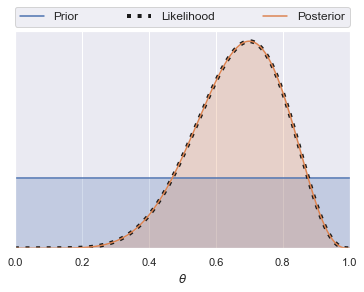

In [3]:
bayes_learn(k=7, n=10, prior='flat')

With a "flat prior", posterior = likelihood.  The frequentist and Bayesian approaches give the same results.

What we learn after one failure, given a flat prior:

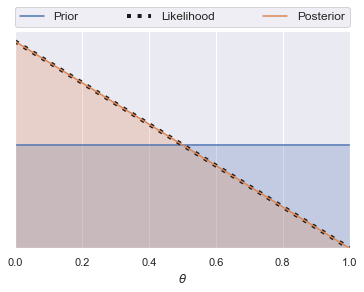

In [4]:
bayes_learn(k=0, n=1, prior='flat')

What we learn after one success, given a flat prior:

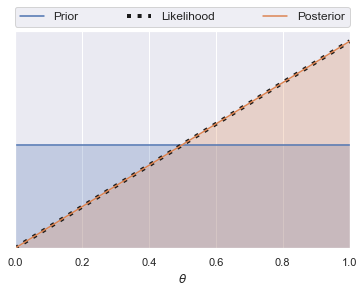

In [5]:
bayes_learn(k=1, n=1, prior='flat')

More realistically, we have prior information about the process. For example, we believe that success is relatively unlikely:

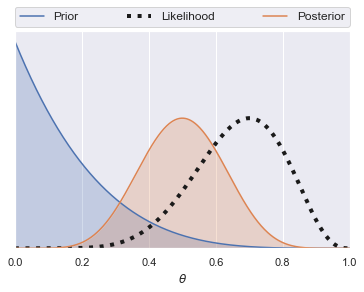

In [6]:
bayes_learn(k=7, n=10, prior='unlikely')

- the posterior is a weighted average of the prior and the likelihood

And here are the one-failure and one-success updates with an informative prior:

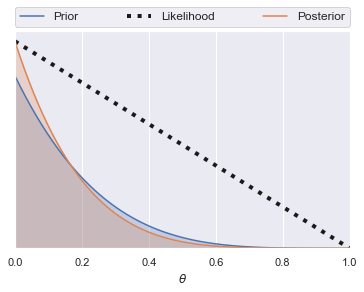

In [7]:
bayes_learn(k=0, n=1, prior='unlikely')

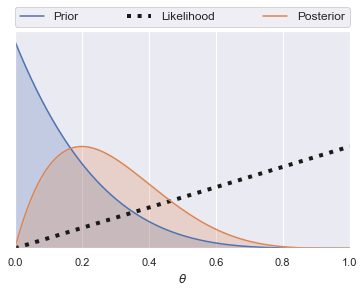

In [8]:
bayes_learn(k=1, n=1, prior='unlikely')

### Why is Bayesian inference hard?

We are interested in the posterior:
$$
P(\Theta_M\mid D, M) = \frac{P(D\mid \Theta_M, M)\,P(\Theta_M\mid M)}{P(D\mid M)}
$$

The likelihood and prior are generally computable, but the normalization constant $P(D\mid M)$ requires an integral over all possible parameters:
$$
P(D\mid M) = \int d\Theta_M'\, P(D\mid \Theta_M', M)\,P(\Theta_M'\mid M)
$$

In rare cases, the normalization constant can be calculated analytically.

In most cases, an approximate method is required.  Two good options:
 - Markov-Chain Monte Carlo (MCMC), dating back to the 1950s; the widely used Hamiltonian Monte Carlo dates back to the late 1980s.
 - Variational Inference (VI), dating back to (at least) the 1970s.

The underlying assumptions and numerical algorithms involved (sampling and optimization) are fundamentally different, leading to different trade-offs between these methods.

## Method 1: Analytical computation

Certain combinations of likelihood and prior functions give an evidence integral that can be performed analytically.

In some special cases, the resulting posterior has the same general functional form as the prior. We then say that the prior and likelihood are **conjugate**.

There are only a few useful cases like this, but they include some important distributions, e.g.
 - Gaussian + Gaussian
 - Poisson + Gamma
 - Bernoulli + Beta
 - Categorical + Dirichlet

The full list is [here](https://en.wikipedia.org/wiki/Conjugate_prior#Table_of_conjugate_distributions).

## Method 2: Markov-Chain Monte Carlo

### Markov-Chain Formalism

A **stochastic process** is basically a black-box generator of random sequences
$$
x_0, x_1, x_2, \ldots
$$

In general, the value $x_n$ depends on the history of all previous samples, so the black box has long-term memory.

A (first-order) **Markov chain** is a special case where $x_n$ only depends *directly* on $x_{n-1}$: a black box with very short-term memory.

A (time) **homogeneous** Markov chain uses the same 'rule' $P(X_n\mid X_{n-1})$ to generate $x_n$ from $x_{n-1}$ for all $n$.

A (time) **reversible** Markov chain has the same probabilistic 'rule' going in either direction, $P(X_n\mid X_{n-1}) = P(X_{n-1}\mid X_n)$.

In practice, a Markov chain is fully specified by two probabilistic 'rules':
 - $P(X_0)$: generate an initial value $x_0$.
 - $P(X_n\mid X_{n-1})$: Generate the next value $x_n$ from the previous value $x_{n-1}$.

Under certain conditions, a Markov chain converges to a unique **equilibrium** (limiting stationary) distribution, which can be thought of as the long-run distribution of the chain that can be reached no matter where we start.

For a reversible Markov chain, it is easier to check that it has an equilibrium distribution, and **design the transition 'rule' $P(X_n\mid X_{n-1})$** so that the chain has a specific equilibrium distribution, namely:
- the posterior distribution we want to estimate.  

Let's define a reversible Markov chain, which is also an example of MCMC (from Kruschke's *Doing Bayesian Data Analysis*). The story goes as follows.

A politician visits a chain of islands as part of their political campaign.

- the politician wants to visit each island in proportion to its population, i.e., visit islands with higher populations more often;
- the politician does not know the population distribution, i.e., the proportion of the total population that lives on each island, because the politician does not know the total population of the islands (the normalizing constant);
- but the politician can find out the (unnormalized) population of the island they are currently on, and the (unnormalized) population of adjacent islands.

Assume the politician starts on a random island, so  $P(X_0)$ is discrete uniform.

The politician uses the following rule, that is, $P(X_n\mid X_{n-1})$, to determine which island to visit next:

- each day, the politician chooses a neighboring island randomly, and compares the population there with the population of the current island;
- if the neighboring island has a larger population, the politician goes there;
- if the neighboring island has a smaller population, then the politician visits with probability $p=\frac{population_{neighbor}}{population_{current}}$; otherwise the politician stays on the same island.



After doing this for many days:

- the politician ends up spending time on each island proportional to the population of each island
- this is the (limiting) stationary distribution of the Markov chain


Thus, the chain estimates the distribution of island populations correctly.

In [9]:
def make_islands(n, low=10, high=101):
    """
    Generate islands with random population between low and high.
    Args:
        n: Number of islands in chain
        low:  minimum population of an island
        high: maximum population of an island

    Return:
        A vector of length n+2.  The first and last entries are 0.  The entry
        in position i represents the population of island i, which is between
        low and high
    """
    # generate the populations are random integers
    islands = np.random.randint(low, high, n+2)
    # first and last islands have 0 population
    islands[0] = 0
    islands[-1] = 0
    return islands

def hop(islands, start=1, niter=1000):
    """
    This function simulates the politician travelling between islands

    Args:
        islands: vector of island populations, created by make_islands function
        start:  number of island on which the politician starts his canvasing
        niter:  number of interations (days the politician spends canvasing)

    Return:
        The vector samples, in which position i indicates the number of the island
        on which the position is located on day i
    """
    # starting island number
    pos = start
    # starting island population
    pop = islands[pos]
    # create empty vector to hold island indices
    samples = np.zeros(niter+1, dtype='int')
    # first day is spent on island with index pos, defined above
    samples[0] = pos
    # loop through each day of travel
    for i in range(niter):
        # generate sample from proposal distribution
        # -1 represents a step to a lower number island
        # 1 represents a step to a higher number island
        k = np.random.choice([-1, 1], 1)
        # next proposed island
        next_pos = pos + k
        # evaluate unnormalized target distribution at proposed position
        # get population of next proposed island
        next_pop = islands[next_pos]
        # calculate acceptance probability
        # this is ratio populations
        # probability cannot be greater than 1, so we take minimum
        p = min(1, next_pop/pop)
        # use uniform random to decide accept/reject proposal
        if np.random.random() < p:
            # if we accept, update position and population
            pos = next_pos
            pop = next_pop
        # store position at time i+1
        samples[i+1] = pos
    return samples

def plot_islands(islands):
    # plot the true proportions of the total population on each island
    data = islands[1:-1]
    # normalize by total population
    data = data/data.sum()
    # make a barplot
    sns.barplot(x=np.arange(1, len(data)+1), y=data)

Let's generate 10 islands with populations randomly generated between $10$ and $100$:

- integers only, i.e., we sample from a discrete uniform

Assume this is population in thousands.

- we bound the chain of islands with $0$s on either side
- this ensures we always stay on the bounding islands whenever we try to move outside the chain of islands

In [10]:
islands = make_islands(10)
islands

array([ 0, 93, 44, 32, 12, 45, 90, 22, 55, 73, 99,  0])

In [11]:
(islands/islands.sum()).round(2)[1:-1]

array([0.16, 0.08, 0.06, 0.02, 0.08, 0.16, 0.04, 0.1 , 0.13, 0.18])

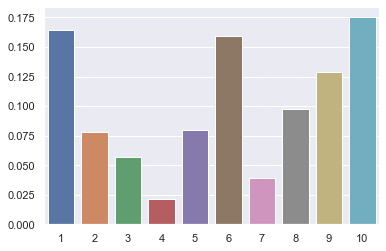

In [12]:
plot_islands(islands)

Let's randomly choose a starting island:

In [13]:
starting_island = np.random.randint(10)
starting_island

6

Let's simulate 10000 days of our politician's campaign trail:

In [14]:
samples = hop(islands, start=starting_island, niter=10000)
samples[:50]

array([ 6,  5,  5,  5,  6,  5,  5,  5,  6,  6,  6,  5,  5,  6,  7,  6,  6,
        5,  5,  5,  5,  6,  6,  6,  6,  6,  5,  6,  6,  6,  6,  6,  6,  6,
        5,  5,  6,  7,  8,  9, 10,  9, 10,  9, 10,  9, 10,  9,  8,  7])

Let's get the counts and the normalized counts (empirical probabilities) for each island:

In [15]:
data = np.bincount(samples)[1:]; print(data)
data = data/data.sum(); data.round(2)

[1811  874  605  218  830 1595  397  967 1212 1492]


array([0.18, 0.09, 0.06, 0.02, 0.08, 0.16, 0.04, 0.1 , 0.12, 0.15])

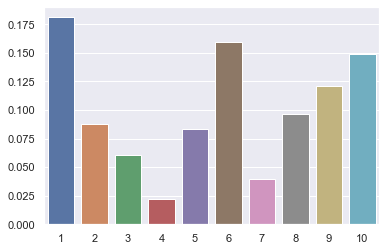

In [16]:
sns.barplot(x=np.arange(1, len(data)+1), y=data);

The influence of the starting point is visible for the first 500 samples or so ...

[156  89  58  14  54  82  11  16  13   7]
[0.31 0.18 0.12 0.03 0.11 0.16 0.02 0.03 0.03 0.01]


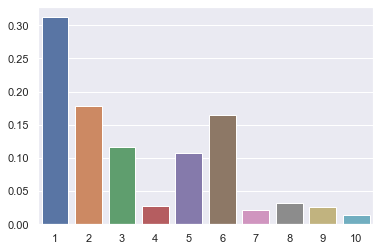

In [17]:
data_first_500 = np.bincount(samples[:500])[1:]; print(data_first_500)
data_first_500 = data_first_500/data_first_500.sum(); print(data_first_500.round(2))
sns.barplot(x=np.arange(1, len(data)+1), y=data_first_500);

... but wanes fairly quickly after that:

[230 108  89  34 113 192  44  67  57  66]
[0.23 0.11 0.09 0.03 0.11 0.19 0.04 0.07 0.06 0.07]


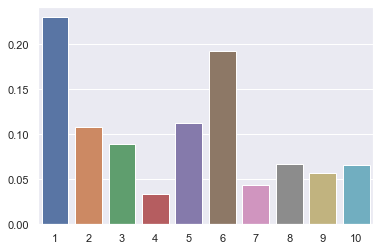

In [18]:
data_next_1000 = np.bincount(samples[500:1500])[1:]; print(data_next_1000)
data_next_1000 = data_next_1000/data_next_1000.sum(); print(data_next_1000.round(2))
sns.barplot(x=np.arange(1, len(data)+1), y=data_next_1000);

For practical applications, there are two issues to deal with:
 - There is no way to know in advance how big $n$ needs to be to achieve equilibrium.
 - Given a Markov chain with an equilibrium distribution, we can generate samples from it, but how do we build a chain to sample a specific distribution $\tilde{P}(X)$?

The second issue requires solving an [inverse problem](https://en.wikipedia.org/wiki/Inverse_problem), which is generally challenging.

However, there is a general family of methods to build a Markov chain with a desired probability density:

 - Metropolis-Hastings-Green
   - Metropolis-Hastings
     - Metropolis
     - Gibbs
     - Hamiltonian

MHG is the most general, but the simpler MH contains the essential ideas so we will focus on that.

### Metropolis-Hastings Updates

The MH algorithm relies on a **proposal distribution** $Q$ that is easier to sample than $\tilde{P}$.

(If you knew how to sample $\tilde{P}$ directly, you would not need MCMC!)

We often use a multivariate Gaussian for $Q$ since it is easy (and efficient) to sample from. Any proposal distribution is valid, but choosing a $Q$ "closer" to $\tilde{P}$ generally reaches the desired equilibrium faster.

The proposal distribution can either be used to update relative to the current state ("random walk"):
$$
X_{n+1} - X_n \sim Q
$$
or else to generate a new independent state each time:
$$
X_{n+1} \sim Q \; .
$$

During each update we evaluate a proposed move to $x_{n+1}$ by calculating the **Hastings ratio**,
$$
r(x_{n+1}, x_n) \equiv \frac{\tilde{P}(x_{n+1})}{\tilde{P}(x_n)}\, \frac{Q(x_n\mid x_{n+1})}{Q(x_{n+1}\mid x_n)} \; ,
$$
where $\tilde{P}$ is the desired equilibrium distribution.

Since $\tilde{P}$ only appears in a ratio, it does not need to be normalized: **this feature is why MCMC is useful for practical Bayesian inference.**

MCMC still requires that you can calculate un-normalized values of $\tilde{P}(x)$.

$$
r(x_{n+1}, x_n) \equiv \frac{\tilde{P}(x_{n+1})}{\tilde{P}(x_n)}\, \frac{Q(x_n\mid x_{n+1})}{Q(x_{n+1}\mid x_n)}
$$

In general, the Hastings ratio is $\ge 0$ but it can otherwise be arbitrarily large.

We always accept a proposed move when $r(x_{n+1}, x_n) \ge 1$.  Otherwise, we accept it with a probability of $0\le r(x_{n+1}, x_n) < 1$.

When a proposed move is rejected, the update returns the original value, so **repetitions of the same output will occur**.

When the proposal distribution $Q$ is symmetric:

- $Q(x_{n+1}\mid x_n) = Q(x_n\mid x_{n+1})$

e.g, uniform or Gaussian, the Hastings ratio simplifies to:

- $r(x_{n+1}, x_n) \equiv \frac{\tilde{P}(x_{n+1})}{\tilde{P}(x_n)}$

This results in the simpler Metropolis algorithm.

Here's a generic implementation of the Metropolis algorithm:

In [19]:
def metropolis(start, target, proposal, niter):
    """start: starting position, target: the target distribution,
    proposal: the proposal distribution, niter: number of iterations"""
    current = start
    samples = [current] # recording starting value
    for i in range(niter):
        proposed = proposal(current) # propose new value
        p = min(target(proposed)/target(current), 1) # acceptance probability
        if np.random.random() < p: # accept or reject proposal
            current = proposed # if accepted, update current value
        samples.append(current) # record current value
    return samples

Applied to the politician's campaign trail:

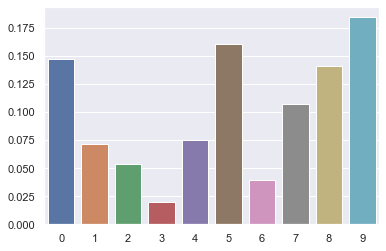

In [20]:
target = lambda x: islands[x] # unnormalized distribution
proposal = lambda x: x + np.random.choice([-1, 1]) # symmetric
samples = metropolis(starting_island, target, proposal, 10000)
data = np.bincount(samples)[1:]; data = data/data.sum()
sns.barplot(x=np.arange(len(data)), y=data);

### A more realistic example: Line Fit with MCMC

Consider fitting a straight line $y = m x + b$, with parameters $m$ and $b$, to data with two features $x$ and $y$.

Use the log-likelihood function:

$$
\log{\cal L}(m, b; D) = -\frac{N}{2}\log(2\pi\sigma_y^2)
-\frac{1}{2\sigma_y^2} \sum_{i=1}^N\, (y_i - m x_i - b)^2 \; ,
$$

where the error in $y$, $\sigma_y$, is a fixed hyperparameter.

First generate some data on a straight line with measurement errors in $y$ (so our assumed model is correct):

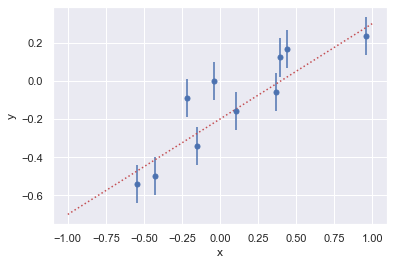

In [21]:
gen = np.random.RandomState(seed=123)
N, m_true, b_true, sigy_true = 10, 0.5, -0.2, 0.1
x_data = gen.uniform(-1, +1, size=N)
y_data = m_true * x_data + b_true + gen.normal(scale=sigy_true, size=N)

plt.errorbar(x_data, y_data, sigy_true, fmt='o', markersize=5)
plt.plot([-1, +1], [-m_true+b_true,+m_true+b_true], 'r:')
plt.xlabel('x'); plt.ylabel('y');

Next, implement the log-likelihood function:
$$
\log{\cal L}(m, b; D) = -\frac{N}{2}\log(2\pi\sigma_y^2)
-\frac{1}{2\sigma_y^2} \sum_{i=1}^N\, (y_i - m x_i - b)^2 \; ,
$$

In [22]:
def loglike(x, y, m, b, sigy):
    norm = 0.5 * len(x) * np.log(2 * np.pi * sigy**2)
    return -0.5 * np.sum((y - m * x - b) ** 2) / sigy**2 - norm

In [23]:
import functools
import inspect

import numpy as np
import pandas as pd

import emcee


def wrap(func, **kwargs):
    """Prepare an arbitrary function to use with emcee sampling.
    Emcee expects its parameters in a single list, but it is sometimes more
    convenient to write a function in terms of named parameters and
    hyperparameters. This method uses introspection to wrap an arbitrary
    function with named parameters so that it has the signature expected
    by emcee.
    For example:
        def f(x,y,a,b): ...
        wrap(f, x=[1], y=[2], a=3, b=4, c=3, d=4)
    returns a tuple (wrapped, ['x','y'], [1,2], {'c':3, 'd':4}) where:
      - wrapped([p,q]) calls f(x=p,y=q,a=3,b=4)
      - [1,2] are the initial values to use for parameters named ['x','y'].
      - {'c':3, 'd':4} are the input kwargs with args of f() removed.
    The square brackets identify floating arguments and specify their initial
    value. An optional callable to evaluate a log-prior can also be passed,
    for example:
        wrap(f, x=[1,px], y=[2,py], a=3, b=4, c=3, d=4)
    where px(x) and py(y) return the (un-normalized) log of the priors on
    x and y to use during posterior sampling.
    Parameters
    ----------
    func : callable
        The function that should be prepared. It is assumed to have only
        numerical arguments that accept any floating point values.
    **kwargs : keyword arguments
        All arguments of func must be included and assigned a value.
        Arguments assigned a floating point value are considered fixed
        during sampling.  Arguments assigned a floating point value
        within a list, e.g., [1.2], will be sampled using the initial
        value provided.  Sampled arguments can optionally also specify
        a log-prior distribution using, e.g. [1.2, lnprior], where lnprior
        is a function of the sampled argument that returns the log prior
        probability density (which does not need to be normalized).
    Returns
    -------
    tuple
        Tuple (wrapped, names, values, kwargs). See example above for details.
    """
    fixed = {}
    names, values, lnpriors = [], [], []
    funcsig = inspect.signature(func)
    try:
        funcargs = {name: kwargs[name] for name in funcsig.parameters}
    except KeyError:
        raise ValueError('Missing arguments.')
    bound = funcsig.bind(**funcargs)
    bound.apply_defaults()
    NoPrior = lambda x: 0.
    for name, value in bound.arguments.items():
        if isinstance(value, list):
            names.append(name)
            values.append(value.pop(0))
            lnpriors.append(value.pop(0) if value else NoPrior)
            if value:
                raise ValueError('Invalid syntax for argument {}.'.format(name))
        else:
            fixed[name] = value
    partial = functools.partial(func, **fixed)
    def wrapped(theta):
        if len(theta) != len(names):
            raise ValueError('expected list of {} values.'.format(len(names)))
        result = 0.
        for lnprior, value in zip(lnpriors, theta):
            result += lnprior(value)
            if not np.isfinite(result):
                # theta is not allowed by this prior.
                return -np.inf
        args = dict(zip(names, theta))
        result += partial(**args)
        return result
    # Remove function args from kwargs.
    for name in funcargs:
        kwargs.pop(name, None)
    return wrapped, names, values, kwargs


def sample(func, names, values, nwalkers=20, nsamples=1000, abs_rms=1e-4,
           frac_rms=1e-3, burnin=100, random_state=None):
    """Generate MCMC samples of the un-normalized PDF func() using emcee.
    Can be used standalone but intended to work with :func:`wrap`.
    Initial values for each walker are Gaussian samples centered on the
    input values with an RMS of max(abs_rms, frac_rms * values).
    Parameters
    ----------
    func : callable
        Evaluate the log PDF to sample. Passed a single list of parameter
        values. Can be prepared using :func:`wrap`.
    names : iterable
        List of names for each floating parameter.  Used to label columns
        in the returned DataFrame. Can be prepared using :func:`wrap`.
    values : iterable
        List of initial values for each floating parameter.  Used to center
        random initial values for each walker. Can be prepared using
        :func:`wrap`.
    nwalkers : int
        The number of emcee walkers to use.
    nsamples : int
        The total number of samples to return, after combining walkers
        and trimming initial burnin.
    abs_rms : float
        Used to set walker initial values.  See above for details.
    rel_rms : float
        Used to set walker initial values.  See above for details.
    burnin : int
        The number of samples to remove from each walker's chain.
    random_state : np.random.RandomState or None
        The random state to use for reproducible chains.
    Returns
    -------
    pandas.DataFrame
        Generated samples in a dataframe, using the inputs names for columns.
    """
    if random_state is None:
        random_state = np.random.RandomState()
    # Generate sampler starting points.
    ndim = len(names)
    values = np.array(values, float)
    initial = np.tile(values, (nwalkers, 1))
    rms = np.maximum(abs_rms, frac_rms * values)
    initial += rms * random_state.normal(size=(nwalkers, ndim))
    # Initialize and run sampler.
    sampler = emcee.EnsembleSampler(nwalkers, ndim, func)
    n_per_chain = 1 + nsamples // nwalkers + burnin
    sampler.run_mcmc(initial, n_per_chain, rstate0=random_state.get_state())
    # Remove burnin and return results in a DataFrame.
    chain = sampler.chain[:, burnin:].reshape(-1, ndim)[:nsamples]
    return pd.DataFrame(chain, columns=names)


def MCMC_sample(func, **kwargs):
    """Generate random samples from an un-normalized PDF.
    See :func:`wrap` and :func:`sample` for details.
    Parameters
    ----------
    func : callable
        Function to evaluate log(f(...)) where f(...) is proportional
        to the desired probability density.  Will be wrapped to
        determine which arguments are sampled and which are fixed.
    **kwargs : keyword arguments
        Used to configure the wrapping of func and the sampler.
    Returns
    -------
    pandas.DataFrame
        Generated samples in a dataframe, with one named column per
        sampled argument of the input function.
    """
    # Wrap the input function.
    wrapped, names, values, kwargs = wrap(func, **kwargs)
    # Generate emcee samples.
    return sample(wrapped, names, values, **kwargs)

Finally, generate some MCMC samples of the posterior $P(m, b\mid D, M)$ assuming uniform priors $P(b,m\mid \sigma_y) = 1$:

In [24]:
def MCMC(func, m, b):
    return MCMC_sample(
        func, m=m, b=b, x=x_data, y=y_data, sigy=sigy_true,
        nsamples=10000, random_state=gen)

In [25]:
def jointplot(x, y, data):
    sns.jointplot(x, y, data, xlim=(0.3,0.8), ylim=(-0.3,0.0), stat_func=None, height=4.5, joint_kws={'s': 5});

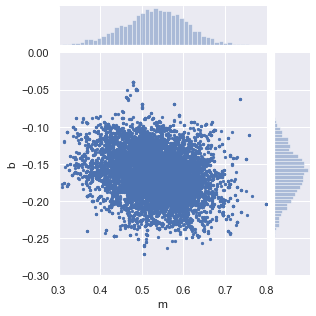

In [26]:
samples = MCMC(loglike, m=[m_true], b=[b_true]);
jointplot('m', 'b', samples)

We always require a starting point to generate MCMC samples. In the last example, we used the true parameter values as starting points:

`m=[m_true], b=[b_true]`

What happens if you chose different starting points?

In [27]:
samples2 = MCMC(loglike, m=[m_true+0.1], b=[b_true+0.1])

In [28]:
samples.describe(percentiles=[])

,m,b
count,10000.000000,10000.000000
mean,0.531518,-0.163364
std,0.074150,0.032178
min,0.277887,-0.271737
50%,0.533564,-0.162615
max,0.799155,-0.039917


In [29]:
samples2.describe(percentiles=[])

,m,b
count,10000.000000,10000.000000
mean,0.526889,-0.164017
std,0.071437,0.033185
min,0.287060,-0.263188
50%,0.524377,-0.164970
max,0.800168,-0.051169


The changes are small compared with the offsets ($\pm 0.1$) and the parameter uncertainties.

The inference above assumes flat priors for $m$ and $b$, but you can add any log-prior to our log-likelihood to change this.

For example, suppose our prior belief is that $0.4 \le m \le 0.7$:

In [30]:
def TopHat(lo, hi):
    """Return un-normalized log(prior) for x in [lo,hi]"""
    return lambda x: 0 if (lo <= x <= hi) else -np.inf

def Gauss(mu, sigma):
    """Return un-normalized log(prior) for x ~ N(mu,sigma)"""
    return lambda x: -0.5 * ((x - mu) / sigma) ** 2

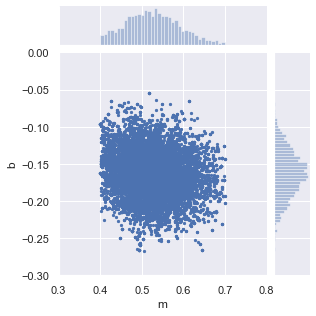

In [31]:
samples = MCMC(loglike, m=[m_true, TopHat(0.4,0.7)], b=[b_true])
jointplot('m', 'b', samples)

Perhaps we also have a prior measurement that found $b = -0.20 \pm 0.02$ (in which case, the new data is not adding much information about $b$):

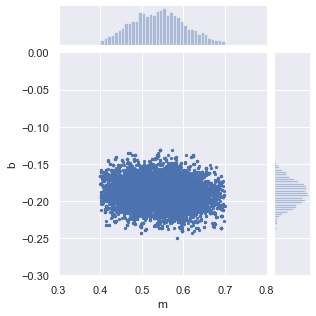

In [32]:
samples = MCMC(loglike,
               m=[m_true,TopHat(0.4,0.7)],
               b=[b_true,Gauss(-0.20,0.02)])
jointplot('m', 'b', samples)

### Practical Advice for MCMC

It is tempting to assume that MCMC samples have desirable properties beyond their minimum guarantees, since this is often true, but avoid this temptation.

MCMC samples are only guaranteed to sample your target $\tilde{P}$ after some unknown number of samples:

**Burn-in?** Should I throw away the first $B$ samples to ensure that my chain is independent of its initial starting point?
 - **No:** There is no practical way to know how big $B$ should be. Instead, ensure that your starting point is reasonably probable (according to $\tilde{P}$) and use all samples. If you do not know how to chose a reasonably probably starting point, you need to solve a separate optimization problem before you are ready to use MCMC (which is notoriously inefficient at discovering new regions of high probability).

There are no useful guarantees about the correlation between $X_{n+k}$ and $X_n$ being small and, in general, you should assume that the consecutive samples in any stretch of the chain are highly correlated.

**Thinning?** Should I just keep every $T$-th sample so that my chain is uncorrelated?
 - **No:** There is no practical way to know in advance how big $T$ should be, and you can never get a better answer (for a fixed amount of computation) by throwing away valid information. Just accept that samples are correlated.

How long should your chain be?

You should ideally use empirical measurements to determine $k$ such that the [autocorrelation](https://en.wikipedia.org/wiki/Autocorrelation)
$$
\frac{\langle (X_{n+k} - \mu) (X_n - \mu)\rangle}{\sigma^2} \simeq 0 \; ,
$$
where $\mu$ and $\sigma$ are the long-term mean and standard deviation of $\tilde{P}(X_n)$, then generate a chain whose length is at least 10-100 times this [autocorrelation](https://en.wikipedia.org/wiki/Autocorrelation) length $k$.

For Gibbs samplers, the Gelman & Rubin ($\hat{R}$) metric is also popular.

Which update rule should you use?

Determine which special cases apply to your target $\tilde{P}$, so you know which algorithms are possible.
 - Can you efficiently sample from a complete set of conditional distributions?  If so, add Gibbs sampling to your list.
 - Can you compute all partial derivatives? If so, add Hamiltonian MC to your list.

There is no "best" algorithm, so you will need to benchmark your problem against the available methods.

Although it is instructive (and fun!) to implement simple update rules yourself, for serious work you should generally let someone else do the hard work for you by using an existing package.

Which package should you use?
 
- [Stan](https://mc-stan.org/) and [PyMC3](http://docs.pymc.io/notebooks/getting_started.html) (based on Theano) are the most widely used nowadays; they both implement HMC etc.; if you want to learn how to do Bayesian inference well for realistically complex models, you'll probably end up using both of them;  
- [Edward](http://edwardlib.org/) (based on tensorflow) or [Pyro](https://pyro.ai/) (based on PyTorch) are more recent additions; possibly the next gen b/c of ease of GPU usage.

## Method 3: Variational Inference

The essence of variational inference (VI) is to first define a family of PDFs that balance two competing criteria:
 - convenient for calculations, and
 - flexible enough to approximately match some unknown target PDF.

We then select the family member that is "closest" to the target.

In a Bayesian context, our target PDF is a posterior distribution.

(However VI is a more general technique for finding approximate PDFs.)

### Kullback-Leibler Divergence

VI relies on a concept of "closeness" between two PDFs $q(\theta)$ and $p(\theta)$.

VI traditionally uses the [Kullback Leibler (KL) divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) to measure the "closeness" of PDFs $q(\theta)$ and $p(\theta)$:

$$
\boxed{
\text{KL}( q \parallel p ) \equiv \int d\theta\, q(\theta)\, \log\frac{q(\theta)}{p(\theta)}}
$$

KL divergence is not symmetric: $\text{KL}(q\parallel p) \neq \text{KL}(p\parallel q)$.
- exchanging $q$ and $p$ in the integrand changes its value. This makes KL divergence an unusual measure of separation and means that it is not a true
[metric](https://en.wikipedia.org/wiki/Metric_%28mathematics%29).

$\text{KL}(q\parallel p) = 0$ when $p=q$.
- this is what we would expect for a useful measure of separation.

KL divergence is not bounded from above:
-  a PDF is always $\ge 0$ but not bounded from above.

KL divergence is always $\ge 0$:
- nothing prevents $q < p$, so the integrand can be negative (due to the log) even with $p, q \ge 0$
- but the integral is always $\ge 0$; the proof relies on [Jensen's inequality](https://en.wikipedia.org/wiki/Jensen's_inequality).

In [33]:
def KL_best_fit(*show):

    # Tabulate p, q1, q2
    x = np.linspace(-2.5, 2.5, 501)
    F = {
        'p': 0.8 * scipy.stats.norm.pdf(x, -1, 0.3) + 0.2 * scipy.stats.norm.pdf(x, +1, 0.3),
        'q_1': scipy.stats.norm.pdf(x, -1, 0.3),
        'q_2': scipy.stats.norm.pdf(x, 0, 0.9),
    }
    # Tabulate integrands of KL(q1||p), KL(q2||p), KL(p||q1), KL(p||q2).
    I = {
        (f,g): F[f] * (np.log(F[f]) - np.log(F[g])) for (f, g) in (
            ('q_1', 'p'), ('q_2', 'p'), ('p', 'q_1'), ('p', 'q_2'))
    }
    # Calculate the KL integrals.
    KL = { pair: np.trapz(integrand, x) for (pair, integrand) in I.items() }

    fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

    ax[0].fill_between(x, F['p'], color='b', lw=0, alpha=0.2)
    ax[0].plot(x, F['p'], 'b-', label='$p$')
    ax[0].plot(x, F['q_1'], 'r-', label='$q_1$')
    ax[0].plot(x, F['q_2'], 'g-', label='$q_2$')
    ax[0].legend(fontsize='x-large')
    ax[0].set_xlim(x[0], x[-1])
    ax[0].set_ylim(-0.01, None)
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    for (f, g) in show:
        label = f'KL$({f}\parallel\,{g}) = {KL[(f, g)]:.3f}$'
        color = 'r' if f.endswith('1') or g.endswith('1') else 'g'
        ax[1].plot(x, I[(f, g)], '--', c=color, label=label)
    ax[1].axhline(0., c='k', ls='-', alpha=0.5)
    ax[1].set_yticks([])
    if any(show): ax[1].legend(fontsize='x-large')

    plt.tight_layout()

Consider the distribution $p$ and the two approximating distributions $q_1$ and $q_2$.

Which one of the 2 distributions minimizes forward KL ($\text{KL}(p\parallel q)$), and which one minimizes reverse KL ($\text{KL}(q\parallel p)$)?

(We focused on reverse KL before.)

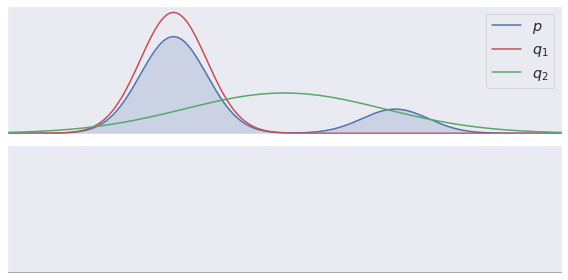

In [34]:
KL_best_fit()

**Forward KL** ($\text{KL}(p\parallel q)$) chooses a $q$ that covers all of $p$:
- the difference between $p(\theta)$ and $q(\theta)$ is weighted by $p(\theta)$
- when $p(\theta)=0$, it does not matter what the other term of the integrand is 
    - ok to have large differences between $p(\theta)$  and $q(\theta)$
    - during optimization, $q(\theta)$ is ignored whenever $p(\theta) = 0$
- if $p(\theta) > 0$, then the other term of the integrand contributes to the KL value, so during optimization, the difference between $p(\theta)$ and $q(\theta)$ will be minimized
- forward KL is $0$ avoiding: it avoids regions where $q(\theta) = 0$ whenever $p(\theta) > 0$

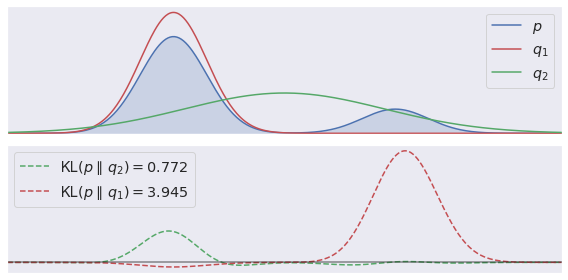

In [35]:
KL_best_fit(('p', 'q_2'), ('p', 'q_1'))

**Reverse KL** ($\text{KL}(q\parallel p)$) chooses a $q$ that fits inside of $p$:

- now $q(\theta)$ is the weight, so if $q(\theta)=0$, there is no penalty for ignoring the value $p(\theta)$
- if $q(\theta)>0$, we minimize the difference between $p(\theta)$ and $q(\theta)$ during optimization
- hence, it is better for $q$ to fit just some part of $p$, as long as $q$ is $0$ for the other parts of $p$
- reverse KL is $0$ forcing: $q(\theta)$ is forced to be $0$ when $p(\theta) > 0$ because that reduces the KL integrand to $0$ 

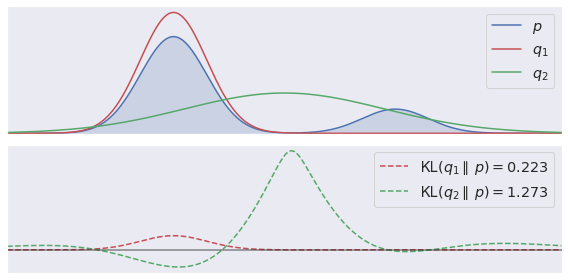

In [36]:
KL_best_fit(('q_1', 'p'), ('q_2', 'p'))

Since $q$ is a PDF, KL divergence can also be written as a difference of expectation values over $q$:
$$
\text{KL}( q \parallel p ) = \langle \log q(\theta)\rangle_q - \langle \log p(\theta)\rangle_q \; .
$$

This turns out to be very useful since it allows KL divergence to be numerically estimated using samples from $q$.

We call this **Stochastic Variational Inference** (SVI).

We use the **reverse KL** for SVI because we generally cannot sample from $p$ but can pick $q$ that is easy to sample.

The KL divergence is a generic method to find the parameterized PDF $q(\theta,s)$ that "best" approximates some target PDF $p(\theta)$.

For Bayesian inference, the $p$ we care about is the posterior:
$$
p(\theta) = P(\theta\mid D) = \frac{P(D\mid \theta)\, P(\theta)}{P(D)} \; .
$$

Since we generally cannot calculate the evidence $P(D)$, a practical inference method should not require that we know its value.

The **variational Bayesian inference** method has three steps:
 - Define a family of PDFs $q(\theta; s)$ that approximate the true posterior $P(\theta\mid D)$.
 - Use optimization to find the value $s^\ast$ that, according to the KL divergence, best approximates the true posterior.
 - Use $q(\theta; s=s^\ast)$ as an approximation of the true posterior for calculating posterior expectations etc.

The main tradeoff is in picking the approximate PDF family $q$.

A more flexible choice will generally do a better job of approximating the true posterior, but also require more difficult calculations.

($\theta$ are called latent variables and $s$ variational parameters)

Two cases for approximating a distribution $p^{*}$ with a distribution $q$ in a family of distributions $Q$:
- $p^{*}\notin Q$ (the most common case in practice)
- $p^{*}\in Q$.

<!-- Original notebook referenced missing local image VI_KL.png here. -->

Plugging the posterior into the KL definition, we can rewrite:
$$
\begin{aligned}
\text{KL}(q\parallel p) &= \int d\theta\, q(\theta) \left[\log P(D) +
\log\frac{q(\theta)}{P(\theta)} - \log P(D\mid\theta) \right] \\
&= \log P(D) + \text{KL}(q\parallel P(\theta)) - \int d\theta\, q(\theta) \log P(D\mid\theta) \; .
\end{aligned}
$$

The three terms on the right-hand side are:
 - The log of the evidence $P(D)$
 - The KL divergence of $q(\theta)$ with respect to the prior $P(\theta)$
 - The $q$-weighted log-likelihood of the data

$$
\text{KL}(q\parallel p) =
\log P(D) + \text{KL}(q\parallel P(\theta)) - \int d\theta\, q(\theta) \log P(D\mid\theta)
$$

 - The log of the evidence $\log P(D)$ is a constant offset in the sum, independent of $q$
 - The KL divergence term $\text{KL}(q\parallel P(\theta))$ is minimized when $q(\theta) = P(\theta)$, i.e., it drives $q$ to look like the prior
 - The log-likelihood term is minimized when $q(\theta)$ prefers parameters $\theta$ that explain the data
    - this is the [cross entropy](https://en.wikipedia.org/wiki/Cross_entropy) of $q(\theta)$ and $P(D\mid\theta)$ (a familiar loss function), which is minimized when they are equal

Since $q$ is normalized, it can only increase the weight of certain $\theta$ values by decreasing the weight of others, so there is a competition between the last two terms.
- exactly what we need for a useful learning rule that balances prior knowledge with the information gained from new data

Let the negative **evidence lower bound (ELBO)** be the KL divergence $\text{KL}(q\parallel p)$ up to the constant $\log P(D)$:

$$
\boxed{
-\mathrm{ELBO}(q) \equiv \text{KL}(q\parallel P(\theta)) - \int d\theta\, q(\theta) \log P(D\mid\theta)
}
$$

If we want to minimize $\text{KL}(q\parallel p)$, we only need to minimize $-\text{ELBO}(q)$, or maximize $\text{ELBO}(q)$), which does not depend on the evidence $P(D)$. **This property is what makes VI practical for Bayesian inference.**

The ELBO can also be evaluated in terms of expectation values,

$$
\begin{aligned}
\mathrm{ELBO}(q) &= \int d\theta\, q(\theta) \log P(D\mid\theta) - \text{KL}(q\parallel P(\theta)) \\
&= \int d\theta\, q(\theta) \log P(D\mid\theta) - \int d\theta\, q(\theta) \log\frac{q(\theta)}{P(\theta)}\\
&= \int d\theta\, q(\theta) \log \left[ P(D\mid\theta) P(\theta)\right] - \int d\theta\, q(\theta) \log q(\theta)\\
&= \langle \log \left[ P(D\mid\theta) P(\theta)\right]\rangle_q - \langle \log q\rangle_q
\end{aligned}
$$

The practical significance of this fact is that we can estimate the ELBO using averages of known quantities calculated with (finite) samples drawn from $q$ (Monte Carlo integration with [importance sampling](https://en.wikipedia.org/wiki/Importance_sampling)).

In [37]:
def calculate_KL(log_q, log_p, theta):
    """Calculate the KL divergence of q wrt p for single-parameter PDFs.
    Uses the trapezoid rule for the numerical integration. Integrals are only
    calculated over the input theta range, so are not valid when p or q have
    significant mass outside this range.
    Regions where either PDF is zero are handled correctly, although an
    integrable singularity due to p=0 will result in a divergent KL because the
    inputs are tabulated.
    Parameters
    ----------
    log_q : array
        Values of log q(theta, s) tabulated on a grid with shape (ns, ntheta)
        of s (axis=0) and theta (axis=1).
    log_p : array
        Values of log p(theta) tabulated on a grid with shape (ntheta) of theta.
    theta : array
        Values of theta where log_q and log_p are tabulated.
    Returns
    -------
    tuple
        Tuple (KL, integrand) where KL is an array of ns divergence values and
        integrand is an array with shape (ns, ntheta) of KL integrands.
    """
    # special handling for q=0.
    q_log_q = np.zeros_like(log_q)
    nonzero = log_q > -np.inf
    q_log_q[nonzero] = log_q[nonzero] * np.exp(log_q[nonzero])
    integrand = q_log_q - log_p * np.exp(log_q)
    return np.trapz(integrand, theta), integrand

def calculate_ELBO(log_q, log_likelihood, log_prior, theta):
    """Calculate the ELBO of q for single-parameter PDFs.
    """
    KLqP, integrand = calculate_KL(log_q, log_prior, theta)
    integrand = np.exp(log_q) * log_likelihood - integrand
    return np.trapz(integrand, theta), integrand


def plot_ELBO(q, q_scale_range, likelihood, prior, theta_range, n_data, seed=123):
    """Explanatory plots for the evidence lower bound (ELBO).
    Data is modeled with a single offset (loc) parameter theta with an arbitrary
    likelihood and prior. A random sample of generated data is used to calculate
    the posterior, which is approximated by adjusting the scale parameter of
    the arbitrary PDF family q.
    Parameters
    ----------
    q : str
        Name of a 1D continous random variable defined in scipy.stats.
    q_scale_range : list
        List [lo, hi] giving the range of scale factors to allow in defining the
        q family of PDFs.
    likelihood : str
        Name of a 1D continous random variable defined in scipy.stats.
    prior : str
        Name of a 1D continous random variable defined in scipy.stats.
    theta_range : list
        List [lo, hi] giving the range to use for plotting and integration.
        The true value of theta used to generate data is (lo + hi) / 2.
    n_data : int
        Number of data points to generate by sampling from the likelihood with
        theta = theta_true.
    seed : int
        Random number seed to use for reproducible results.
    """
    q = getattr(scipy.stats, q)
    likelihood = getattr(scipy.stats, likelihood)
    prior = getattr(scipy.stats, prior)

    # Generate random data using the midpoint of the theta range as the
    # true value of theta for sampling the likelihood.
    theta = np.linspace(*theta_range, 251)
    theta_true = 0.5 * (theta[0] + theta[-1])
    D = likelihood.rvs(
        loc=theta_true, size=n_data,
        random_state=np.random.RandomState(seed=seed))

    # Calculate the likelihood and prior for each theta.
    log_L = likelihood.logpdf(D, loc=theta[:, np.newaxis]).sum(axis=1)
    log_P = prior.logpdf(theta)

    # Calculate the evidence and posterior.
    log_post = log_L + log_P
    log_evidence = np.log(np.trapz(np.exp(log_post), theta))
    log_post -= log_evidence
    assert np.all(np.isfinite(log_post))

    q_scale = np.linspace(*q_scale_range, 101)
    log_q = q.logpdf(theta, scale=q_scale[:, np.newaxis])

    KLs, KL_ints = calculate_KL(log_q, log_post, theta)
    ibest = np.argmin(KLs)

    ELBOs, ELBO_ints = calculate_ELBO(log_q, log_L, log_P, theta)

    fig = plt.figure(figsize=(8, 6))
    ax = [plt.subplot2grid((2,2), (0,0), colspan=2), plt.subplot2grid((2,2), (1,0), colspan=2)]
    cmap = sns.color_palette('bright', n_colors=1 + len(KLs)).as_hex()

    ax[0].plot(theta, np.exp(log_post), '-', lw=10, c=cmap[0],
               alpha=0.25, label='$P(\\theta\mid D)$')
    ax[0].axhline(0., color='gray', lw=1)
    ax[1].axhline(0., color='gray', lw=1)
    for i, idx in enumerate((0, ibest, -1)):
        c = cmap[i + 1]
        label = '$q(\\theta;s={:.2f})$'.format(q_scale[idx])
        ax[0].plot(theta, np.exp(log_q[idx]), '--', lw=2,
                   alpha=1, c=c, label=label)
        ax[1].plot(theta, KL_ints[idx], '--', lw=2, alpha=1, c=c)
    ax[0].legend()
    ax[0].set_ylabel('$p(x), q(\\theta; s)$', fontsize='x-large')
    ax[0].set_xlim(*theta_range)
    ax[0].set_xlabel('$\\theta$', fontsize='large')
    ax[0].set_yticks([])
    ax[1].set_ylabel('KL$(q \parallel p)$ integrand', fontsize='x-large')
    ax[1].set_xlim(*theta_range)
    ax[1].set_xlabel('$\\theta$', fontsize='large')
    ax[1].set_yticks([])

    plt.subplots_adjust(
        left=0.05, right=0.95, hspace=0.25, wspace=0.15, top=0.95)

### Example

Suppose we observe 1D data $x$ that we model with a double exponential (aka [Laplacian](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.laplace.html)) likelihood and one unknown location parameter $\theta$:
$$
P(x\mid \theta) = \frac{1}{2}\, e^{-|x - \theta|} \; .
$$

The resulting likelihood for observations $D = \{x_i\}$ is:
$$
P(D\mid\theta) = \prod_i P(x_i\mid\theta) \; ,
$$

Assume a Gaussian prior. The corresponding posterior
$$
P(\theta\mid D) = \frac{P(D\mid\theta)\, P(\theta)}{P(D)}
$$

is roughly Gaussian, so we use a family $q$ of Gaussians to approximate it, which have $\mu=0$ fixed, and $\sigma = s$ varying.

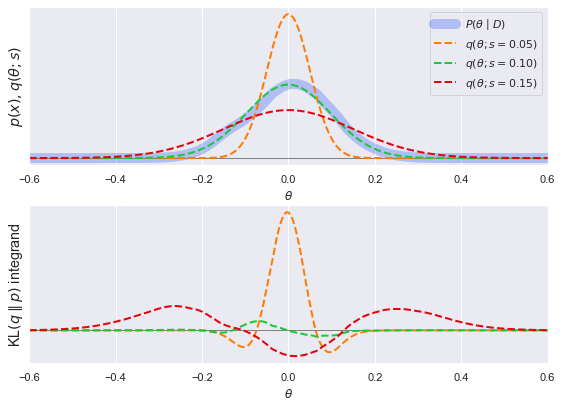

In [38]:
plot_ELBO(q='norm', q_scale_range=[0.05, 0.15],
          likelihood='laplace', prior='norm',
          theta_range=[-0.6, +0.6], n_data=100)

### Practical Calculations with VI

MCMC with Metroplis-Hastings updates can be used as a black box for an arbitrary inference problem that only requires that you can calculate your likelihood $P(D\mid \theta)$ and prior $P(\theta)$ for arbitrary parameter values $\theta$.

VI, on the other hand, generally requires more work to setup for a particular problem, but is then often more computationally efficient since it replaces sampling with optimization.

A necessary step in any VI inference is to select an approximating family $q$, and this generally requires knowledge of the particular problem and some judgment on how to tradeoff calculational convenience against approximation error.

Once you selected a family $q(\theta; s)$ that is explored by some $s$, you need to be able to:
 - evaluate the -ELBO (proxy for KL) of $q(s)$ with respect to $p$ for any $s$, and
 - find the value of $s$ that minimizes the KL divergence.

The first step either requires an analytic integral over $\theta$ or a sufficiently accurate numerical approximation to the ELBO integral.
- the expectation form of the ELBO provides a general-purpose numerical approximation (SVI):
$$
\text{ELBO}(q) = \langle \log \left[ P(D\mid\theta) P(\theta)\right]\rangle_q - \langle \log q\rangle_q
$$

For the second step, we can use standard numerical optimization methods (usually requiring us to evaluate derivatives of $q(s)$ with respect to $s$).

Recall that we use the **reverse KL** for VI since $q$ is (by choice) easy to sample from:

$$
\text{KL}( q \parallel p ) = \langle \log q(\theta)\rangle_q - \langle \log p(\theta)\rangle_q \; .
$$

Contrast with MCMC where the algorithm provides samples of $p$ that allow us to estimate the **forward KL**:

$$
\text{KL}( p \parallel q ) = \langle \log p(\theta)\rangle_p - \langle \log q(\theta)\rangle_p \; .
$$

Therefore:
 - VI finds $q$ that is closest to $p$ according to the **reverse KL**.
 - MCMC enables us to find $q$ that is closest to $p$ according to the **forward KL**.

(but once you have MCMC samples from $p$, we should use them directly instead of summarizing with an approximate $q$)